In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.ar_model import AutoReg
import statsmodels.api as sm
from pandas import Timedelta
import warnings

warnings.filterwarnings('ignore')

In [29]:
class Config_HAR:
    # Lag selection
    use_bic: bool = True
    lag_candidates = [1, 5, 22]
    max_bic_lag = 44

    # Data parameters
    initial_train_years = 4
    test_months = 1

    # Transformations
    use_log_transform = True

In [4]:
def load_and_prepare_data(filepath):
    rv = pd.read_csv(filepath)
    rv = rv[["Date", "Volatility", "Type"]]
    rv.rename(columns={"Volatility": "RV_daily"}, inplace=True)
    rv = rv[rv['Type'] == 'QMLE-Trade']
    rv.drop(columns=['Type'], inplace=True)
    rv = rv.set_index("Date")
    rv.index = pd.to_datetime(rv.index)
    rv.index.name = "date"

    print(f"Data loaded: {len(rv)} observations")
    print(f"Date range: {rv.index.min()} to {rv.index.max()}")
    return rv

def create_lagged_features(data, lags):
    df = data.copy()
    for lag in lags:
        df[f'lag_{lag}'] = df['RV_daily'].shift(lag)
    df = df.dropna()
    return df

def prepare_train_test_data(df, train_start, train_end, test_start, test_end):
    train_data = df[train_start:train_end]
    test_data = df[test_start:test_end]
    return train_data, test_data

In [5]:
def calculate_BIC(rv_data, max_lag: int = 44):
    bic_values = {}
    for lag in range(2, max_lag + 1):
        model = AutoReg(rv_data.iloc[-252:], lags=lag, old_names=False)
        result = model.fit()
        bic_values[lag] = result.bic
    best_lag = min(bic_values, key=bic_values.get)

    chosen = [1]
    if best_lag > 10:
        second_var = int(best_lag * 5/22)
        chosen.append(second_var)
        chosen.append(best_lag)
    else:
        second_var = int(best_lag * 22/5)
        chosen.append(best_lag)
        chosen.append(second_var)

    chosen = sorted(chosen)
    print(f"BIC-selected lag set: {chosen}")
    return chosen

In [6]:
def calculate_mse(y_true, y_pred):
    return mean_squared_error(y_true, y_pred)

def calculate_qlike(y_true, y_pred):
    y_true = np.maximum(y_true, 1e-8)
    y_pred = np.maximum(y_pred, 1e-8)
    qlike = np.mean(y_true / y_pred - np.log(y_true / y_pred) - 1)
    return qlike

In [7]:
def fit_har_model(X, y):
    X_const = sm.add_constant(X, has_constant='add')
    return sm.OLS(y, X_const).fit()

def predict_har_model(model, X):
    X_const = sm.add_constant(X, has_constant='add')
    return model.predict(X_const)

In [8]:
def expanding_window_forecast(rv_data, config):
    # Create lagged features
    if config.use_bic:
        df_with_lags = create_lagged_features(rv_data, list(range(1, config.max_bic_lag + 1)))
    else:
        df_with_lags = create_lagged_features(rv_data, config.lag_candidates)

    all_results = []

    start_date = df_with_lags.index[0]
    initial_train_end = start_date + pd.DateOffset(years=config.initial_train_years)
    current_test_start = initial_train_end + Timedelta(days=1)  # no overlap

    print(f"\nStarting expanding window forecasting...")
    print(f"Initial training period: {start_date.date()} to {initial_train_end.date()}")
    print(f"Test slice per window: {config.test_months} month(s)")
    print(f"Using log transformation: {config.use_log_transform}")
    print(f"Use BIC: {config.use_bic}\n")

    window_count = 0
    last_date = df_with_lags.index[-1]

    while current_test_start <= last_date:
        window_count += 1

        train_start = start_date
        train_end = current_test_start - Timedelta(days=1)
        test_end = min(
            current_test_start + pd.DateOffset(months=config.test_months) - Timedelta(days=1),
            last_date
        )

        # Split data (train/test only)
        train_data, test_data = prepare_train_test_data(
            df_with_lags, train_start, train_end, current_test_start, test_end
        )

        if len(test_data) == 0 or len(train_data) == 0:
            break

        # Select lags
        if config.use_bic:
            selected = calculate_BIC(train_data['RV_daily'], max_lag=config.max_bic_lag)
            feature_cols = [f'lag_{lag}' for lag in selected]
        else:
            feature_cols = [f'lag_{lag}' for lag in config.lag_candidates]
            selected = config.lag_candidates

        # Build matrices
        X_train = train_data[feature_cols].values
        y_train = train_data['RV_daily'].values
        X_test  = test_data[feature_cols].values
        y_test  = test_data['RV_daily'].values

        # Optional log transformation
        if config.use_log_transform:
            X_train_work = np.log(np.maximum(X_train, 1e-8))
            X_test_work  = np.log(np.maximum(X_test, 1e-8))
            y_train_work = np.log(np.maximum(y_train, 1e-8))
        else:
            X_train_work, X_test_work = X_train, X_test
            y_train_work = y_train

        # Fit OLS HAR
        model = fit_har_model(X_train_work, y_train_work)

        # Predict (work space)
        train_pred_work = predict_har_model(model, X_train_work)
        test_pred_work  = predict_har_model(model, X_test_work)

        # Inverse transform if logged
        if config.use_log_transform:
            y_train_level = y_train
            train_pred = np.exp(train_pred_work)
            test_pred  = np.exp(test_pred_work)
        else:
            y_train_level = y_train
            train_pred = train_pred_work
            test_pred  = test_pred_work

        # Metrics
        train_mse = calculate_mse(y_train_level, train_pred)
        test_mse  = calculate_mse(y_test, test_pred)
        train_ql  = calculate_qlike(y_train_level, train_pred)
        test_ql   = calculate_qlike(y_test, test_pred)

        # Log window info
        print(f"--- Window {window_count} ---")
        print(f"Train: {train_start.date()} to {train_end.date()}  (n={len(train_data)})")
        print(f"Test : {current_test_start.date()} to {test_end.date()} (n={len(test_data)})")
        print(f"Lags used: {selected}")
        print(f"In-sample  -> MSE: {train_mse:.6f}, QLIKE: {train_ql:.6f}")
        print(f"Out-of-sample -> MSE: {test_mse:.6f}, QLIKE: {test_ql:.6f}\n")

        # Collect results per test day
        window_df = pd.DataFrame({
            'date': test_data.index,
            'real_RV': y_test,
            'predicted_RV': test_pred,
            'window': window_count,
            'train_mse': train_mse,
            'test_mse': test_mse,
            'train_qlike': train_ql,
            'test_qlike': test_ql,
            'lags_used': [str(selected)] * len(test_data)
        })
        all_results.append(window_df)

        # Advance to next window
        current_test_start = test_end + Timedelta(days=1)

    if not all_results:
        print("No results generated. Check data range and configuration.")
        return pd.DataFrame(columns=['date','real_RV','predicted_RV','window','train_mse','test_mse','train_qlike','test_qlike','lags_used'])

    results_df = pd.concat(all_results, axis=0, ignore_index=True)
    return results_df

In [9]:
def plot_results(results_df):
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))

    # Time series of actual vs predicted
    ax1 = axes[0]
    ax1.plot(results_df['date'], results_df['real_RV'], label='Actual RV', alpha=0.7, linewidth=1)
    ax1.plot(results_df['date'], results_df['predicted_RV'], label='Predicted RV', alpha=0.7, linewidth=1)
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Realised Volatility')
    ax1.set_title('Actual vs Predicted Realised Volatility')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Scatter plot: Actual vs Predicted with 45-degree line
    ax2 = axes[1]
    ax2.scatter(results_df['real_RV'], results_df['predicted_RV'], alpha=0.6, s=10)
    min_val = min(results_df['real_RV'].min(), results_df['predicted_RV'].min())
    max_val = max(results_df['real_RV'].max(), results_df['predicted_RV'].max())
    ax2.plot([min_val, max_val], [min_val, max_val], linestyle='--', linewidth=1)
    ax2.set_xlabel('Actual RV')
    ax2.set_ylabel('Predicted RV')
    ax2.set_title('Predicted vs Actual Realised Volatility')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

def print_summary_statistics(results_df):  # summary statistics of evaluation metrics
    print("\n" + "="*60)
    print("SUMMARY STATISTICS")
    print("="*60)

    # Overall metrics
    overall_mse = calculate_mse(results_df['real_RV'], results_df['predicted_RV'])
    overall_qlike = calculate_qlike(results_df['real_RV'].values, results_df['predicted_RV'].values)

    print(f"\nOverall Out-of-Sample Performance:")
    print(f"MSE: {overall_mse:.6f}")
    print(f"QLIKE: {overall_qlike:.6f}")

    # Average metrics across windows
    avg_train_mse = results_df.groupby('window')['train_mse'].first().mean()
    avg_test_mse = results_df.groupby('window')['test_mse'].first().mean()
    avg_train_qlike = results_df.groupby('window')['train_qlike'].first().mean()
    avg_test_qlike = results_df.groupby('window')['test_qlike'].first().mean()

    print(f"\nAverage Performance Across Windows:")
    print(f"In-Sample - MSE: {avg_train_mse:.6f}, QLIKE: {avg_train_qlike:.6f}")
    print(f"Out-of-Sample - MSE: {avg_test_mse:.6f}, QLIKE: {avg_test_qlike:.6f}")

    # Correlation
    correlation = results_df['real_RV'].corr(results_df['predicted_RV'])
    print(f"\nCorrelation between Actual and Predicted: {correlation:.4f}")

    # Number of windows
    n_windows = results_df['window'].nunique()
    print(f"\nTotal number of expanding windows: {n_windows}")
    print(f"Total predictions made: {len(results_df)}")

HAR OLS MODEL

Loading data...
Data loaded: 7301 observations
Date range: 1996-01-02 00:00:00 to 2025-04-29 00:00:00

Starting expanding window forecasting...
Initial training period: 1996-03-06 to 2000-03-06
Test slice per window: 1 month(s)
Using log transformation: True
Use BIC: True

BIC-selected lag set: [1, 2, 8]
--- Window 1 ---
Train: 1996-03-06 to 2000-03-06  (n=1010)
Test : 2000-03-07 to 2000-04-06 (n=23)
Lags used: [1, 2, 8]
In-sample  -> MSE: 0.004374, QLIKE: 0.106003
Out-of-sample -> MSE: 0.010544, QLIKE: 0.092531

BIC-selected lag set: [1, 2, 8]
--- Window 2 ---
Train: 1996-03-06 to 2000-04-06  (n=1033)
Test : 2000-04-07 to 2000-05-06 (n=20)
Lags used: [1, 2, 8]
In-sample  -> MSE: 0.004470, QLIKE: 0.105747
Out-of-sample -> MSE: 0.011666, QLIKE: 0.071907

BIC-selected lag set: [1, 2, 8]
--- Window 3 ---
Train: 1996-03-06 to 2000-05-06  (n=1053)
Test : 2000-05-07 to 2000-06-06 (n=21)
Lags used: [1, 2, 8]
In-sample  -> MSE: 0.004566, QLIKE: 0.105279
Out-of-sample -> MSE: 0.0

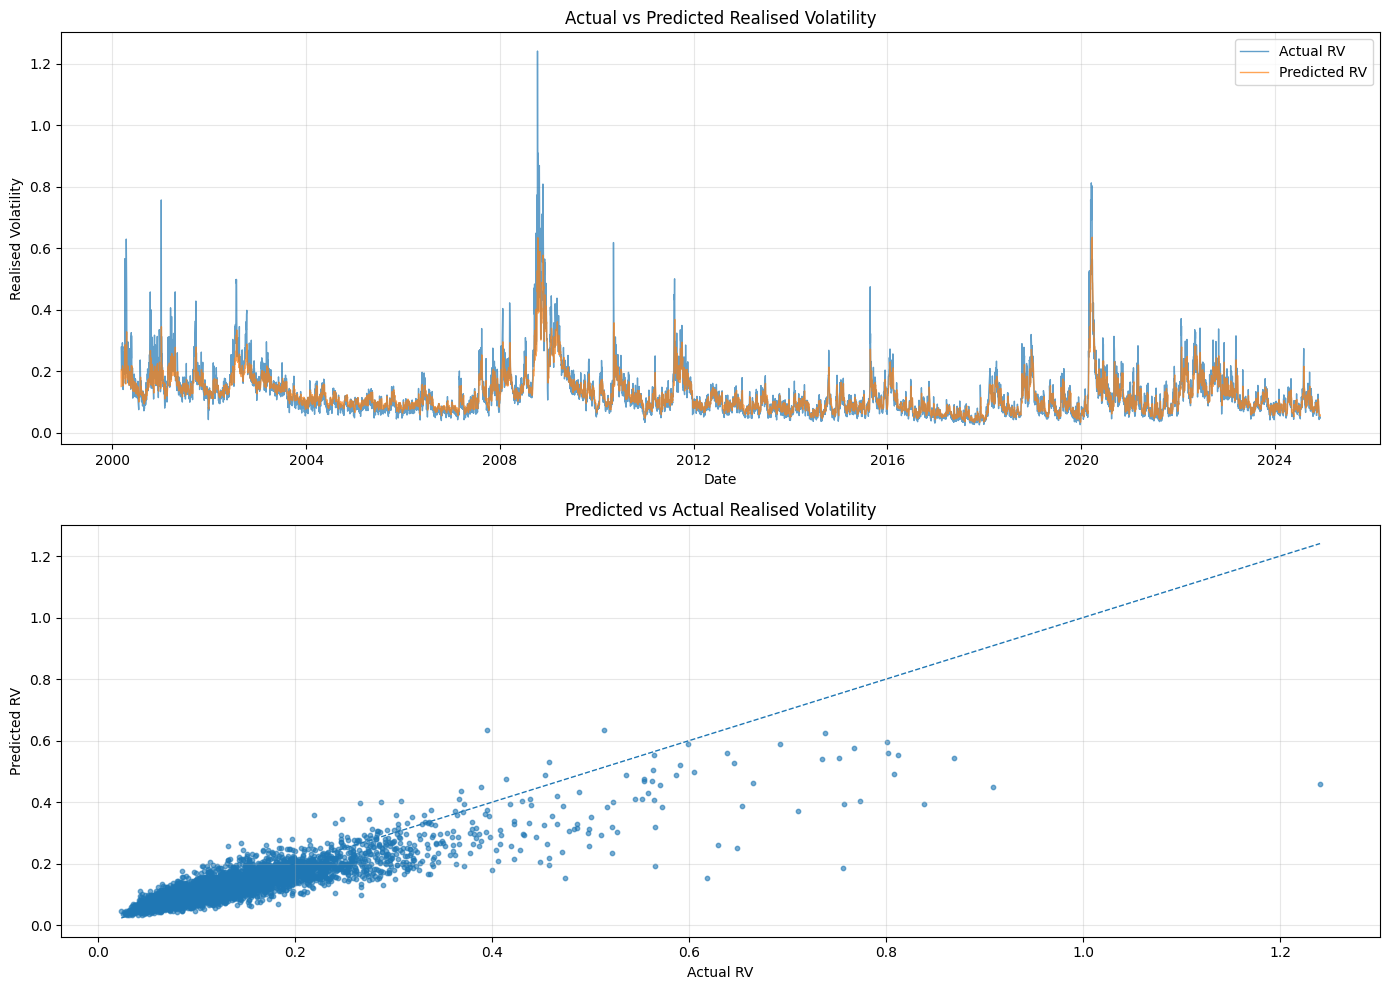

In [30]:
def main_har():
    print("="*60)
    print("HAR OLS MODEL")
    print("="*60)

    # Initialize configuration
    config = Config_HAR()

    # Load data
    print("\nLoading data...")
    rv_data = load_and_prepare_data('SPY.csv')

    # Expanding window forecast
    results_df = expanding_window_forecast(rv_data, config)

    # Save results
    if config.use_bic:
        output_filename = 'har_bic_rv_forecast_results.csv'
    else:
        output_filename = 'har_rv_forecast_results.csv'
    results_df.to_csv(output_filename, index=False)
    print(f"\nResults saved to {output_filename}")

    # Print summary statistics
    print_summary_statistics(results_df)

    # Plot results
    print("\nGenerating plots...")
    plot_results(results_df)

if __name__ == "__main__":
    main_har()


In [2]:
class Config:
    # Feature/lag settings
    use_bic: bool = False       # True -> pick lags via BIC *each window*; False -> fixed (1,5,22)
    max_lag: int = 44                # BIC search upper bound for AutoReg
    feature_mode: str = "mean"       # "mean" (HAR averages) or "lag" (simple lags at 1,w,m)
    threshold_weekly_monthly_split: int = 14  # <= threshold => treat as weekly; else monthly

    # Transform & windows
    use_log_transform: bool = True   # log target (typical for RV)
    initial_train_years: int = 4     # expanding-window initial train size
    test_months: int = 1             # test window size

    # Misc
    ticker: str = "SPY"

In [3]:
def load_and_prepare_data(filepath):
    rv = pd.read_csv(filepath)
    rv = rv[["Date", "Volatility", "Type"]]
    rv.rename(columns={"Volatility": "RV_daily"}, inplace=True)
    rv = rv[rv['Type'] == 'QMLE-Trade']
    rv.drop(columns=['Type'], inplace=True)
    rv = rv.set_index("Date")
    rv.index = pd.to_datetime(rv.index)
    rv.index.name = "date"
    rv.sort_index(inplace=True)

    print(f"Data loaded: {len(rv)} observations")
    print(f"Date range: {rv.index.min().date()} to {rv.index.max().date()}")
    return rv

In [41]:
def choose_weekly_monthly_lags(series: pd.Series, config: Config):
    s = pd.Series(series).dropna().astype(float)

    bic_values = {}
    for lag in range(1, config.max_lag + 1):
        try:
            res = AutoReg(s, lags=lag, old_names=False).fit()
            bic_values[lag] = res.bic
        except Exception:
            # if not enough data for large lag, just skip
            continue

    if not bic_values:
        print("BIC selection failed; defaulting to weekly=5, monthly=22.")
        return 5, 22, None, {}

    best_lag = min(bic_values, key=bic_values.get)
    if best_lag <= config.threshold_weekly_monthly_split:
        weekly = int(max(1, round(best_lag)))
        monthly = int(max(2, round(weekly * 22 / 5)))
        chosen_as = "weekly"
    else:
        monthly = int(max(2, round(best_lag)))
        weekly = int(max(1, round(monthly * 5 / 22)))
        chosen_as = "monthly"

    if monthly == weekly:
        monthly = max(monthly + 1, weekly + 1)

    print("  BIC-based lag selection:")
    print(f"    Best AR lag (min BIC): {best_lag} (treated as {chosen_as})")
    print(f"    Weekly lag: {weekly}, Monthly lag: {monthly}")
    print(f"    BIC value at best lag: {bic_values[best_lag]:.4f}")
    return weekly, monthly, best_lag, bic_values

In [42]:
def create_lagged_features(rv_df: pd.DataFrame,
                           weekly_lag: int,
                           monthly_lag: int,
                           feature_mode: str = "mean") -> pd.DataFrame:
    df = rv_df.copy()
    y = df["RV_daily"].astype(float)

    out = pd.DataFrame(index=df.index)
    out["RV_daily"] = y
    out["lag_1"] = y.shift(1)

    if feature_mode == "mean":
        out["lag_w"] = y.shift(1).rolling(window=weekly_lag, min_periods=weekly_lag).mean()
        out["lag_m"] = y.shift(1).rolling(window=monthly_lag, min_periods=monthly_lag).mean()
    else:  # "lag"
        out["lag_w"] = y.shift(weekly_lag)
        out["lag_m"] = y.shift(monthly_lag)

    out.dropna(inplace=True)
    return out

In [43]:
def calculate_mse(y_true, y_pred):  # MSE
    return mean_squared_error(y_true, y_pred)

def calculate_qlike(y_true, y_pred):
    y_true = np.maximum(np.asarray(y_true).reshape(-1), 1e-8)  # ensure non-zero
    y_pred = np.maximum(np.asarray(y_pred).reshape(-1), 1e-8)
    return float(np.mean(y_true / y_pred - np.log(y_true / y_pred) - 1))

In [44]:
def expanding_window_forecast_HAR(rv_data: pd.DataFrame, config: Config) -> pd.DataFrame:
    """
    For each expanding window:
      1) Define training end and next 1-month test.
      2) If config.use_bic: select weekly/monthly from training slice via BIC; else use (5,22).
      3) Build HAR features for those horizons.
      4) Fit OLS on training, predict test; back-transform if needed; compute metrics.
    """
    start_calendar = rv_data.index[0]
    initial_train_end_calendar = start_calendar + pd.DateOffset(years=config.initial_train_years)
    current_test_start = initial_train_end_calendar

    print(f"\nStarting expanding window forecasting...")
    print(f"Initial training anchor: {start_calendar.date()} to {initial_train_end_calendar.date()}")
    print(f"Using log transformation: {config.use_log_transform}")
    print(f"Feature mode: {config.feature_mode}")

    all_results = []
    window_count = 0

    while current_test_start < rv_data.index[-1]:
        window_count += 1
        train_end = current_test_start - pd.Timedelta(days=1)
        test_end = min(current_test_start + pd.DateOffset(months=config.test_months),
                       rv_data.index[-1])

        print(f"\n--- Window {window_count} ---")
        print(f"Planned Train: {start_calendar.date()} to {train_end.date()}")
        print(f"Planned Test : {current_test_start.date()} to {test_end.date()}")

        # ----- (1) Select lags for THIS window via BIC on training slice -----
        if config.use_bic:
            series_for_bic = rv_data.loc[:train_end, "RV_daily"].astype(float)
            if config.use_log_transform:
                series_for_bic = np.log(series_for_bic + 1e-8)
            weekly_lag, monthly_lag, best_lag, _ = choose_weekly_monthly_lags(series_for_bic, config)
            mode = f"HAR(1,{weekly_lag},{monthly_lag}) [BIC-selected]"
        else:
            weekly_lag, monthly_lag = 5, 22
            best_lag = None
            mode = "HAR(1,5,22) [fixed]"
        print(f"  Mode: {mode}")

        # ----- (2) Build features for selected horizons ----------------------
        df_features = create_lagged_features(rv_data, weekly_lag, monthly_lag, config.feature_mode)

        # Now slice actual train/test rows (some early rows dropped by rolling)
        train_data = df_features.loc[:train_end]
        test_data = df_features.loc[current_test_start:test_end]

        if len(test_data) == 0 or len(train_data) < 30:
            print("  Skipping window (insufficient rows after feature construction).")
            current_test_start = current_test_start + pd.DateOffset(months=1)
            continue

        print(f"  Actual Train rows: {len(train_data)}, Test rows: {len(test_data)}")

        # ----- (3) Prepare matrices and fit OLS ------------------------------
        feature_cols = ["lag_1", "lag_w", "lag_m"]
        X_train = sm.add_constant(train_data[feature_cols].values, has_constant='add')
        X_test = sm.add_constant(test_data[feature_cols].values, has_constant='add')

        y_train_original = train_data['RV_daily'].values
        y_test_original = test_data['RV_daily'].values

        y_train = np.log(y_train_original + 1e-8) if config.use_log_transform else y_train_original

        model = sm.OLS(y_train, X_train).fit()

        # ----- (4) Predict, back-transform, and score ------------------------
        train_pred = model.predict(X_train)
        test_pred = model.predict(X_test)

        if config.use_log_transform:
            train_pred = np.exp(train_pred) - 1e-8
            test_pred = np.exp(test_pred) - 1e-8

        train_mse = calculate_mse(y_train_original, train_pred)
        test_mse = calculate_mse(y_test_original, test_pred)
        train_qlike = calculate_qlike(y_train_original, train_pred)
        test_qlike = calculate_qlike(y_test_original, test_pred)

        print(f"  In-sample  MSE: {train_mse:.6f}, QLIKE: {train_qlike:.6f}")
        print(f"  Out-of-sample MSE: {test_mse:.6f}, QLIKE: {test_qlike:.6f}")

        for i, date in enumerate(test_data.index):
            all_results.append({
                'ticker': config.ticker,
                'date': date,
                'real_RV': float(y_test_original[i]),
                'predicted_RV': float(test_pred[i]),
                'window': window_count,
                'weekly_lag': weekly_lag,
                'monthly_lag': monthly_lag,
                'best_ar_lag': (None if best_lag is None else int(best_lag)),
                'train_mse': float(train_mse),
                'test_mse': float(test_mse),
                'train_qlike': float(train_qlike),
                'test_qlike': float(test_qlike)
            })

        # advance by 1 month (expand training window)
        current_test_start = current_test_start + pd.DateOffset(months=1)

    return pd.DataFrame(all_results)

In [45]:
def plot_results(results_df):
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))

    # Time series of actual vs predicted
    ax1 = axes[0]
    ax1.plot(results_df['date'], results_df['real_RV'], label='Actual RV', alpha=0.7, linewidth=1)
    ax1.plot(results_df['date'], results_df['predicted_RV'], label='Predicted RV', alpha=0.7, linewidth=1)
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Realised Volatility')
    ax1.set_title('Actual vs Predicted Realised Volatility')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Scatter plot
    ax2 = axes[1]
    ax2.scatter(results_df['real_RV'], results_df['predicted_RV'], alpha=0.5, s=10)

    # diagonal line
    min_val = min(results_df['real_RV'].min(), results_df['predicted_RV'].min())
    max_val = max(results_df['real_RV'].max(), results_df['predicted_RV'].max())
    ax2.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.5, label='Perfect Prediction')

    ax2.set_xlabel('Actual RV')
    ax2.set_ylabel('Predicted RV')
    ax2.set_title('Actual vs Predicted RV (Scatter Plot)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('har_rv_forecast_results.png', dpi=300, bbox_inches='tight')
    plt.show()

def print_summary_statistics(results_df):  # summary statistics of evaluation metrics
    print("\n" + "="*60)
    print("SUMMARY STATISTICS")
    print("="*60)

    # Overall metrics
    overall_mse = calculate_mse(results_df['real_RV'], results_df['predicted_RV'])
    overall_qlike = calculate_qlike(results_df['real_RV'].values, results_df['predicted_RV'].values)

    print(f"\nOverall Out-of-Sample Performance:")
    print(f"MSE: {overall_mse:.6f}")
    print(f"QLIKE: {overall_qlike:.6f}")

    # Average metrics across windows
    avg_train_mse = results_df.groupby('window')['train_mse'].first().mean()
    avg_test_mse = results_df.groupby('window')['test_mse'].first().mean()
    avg_train_qlike = results_df.groupby('window')['train_qlike'].first().mean()
    avg_test_qlike = results_df.groupby('window')['test_qlike'].first().mean()

    print(f"\nAverage Performance Across Windows:")
    print(f"In-Sample - MSE: {avg_train_mse:.6f}, QLIKE: {avg_train_qlike:.6f}")
    print(f"Out-of-Sample - MSE: {avg_test_mse:.6f}, QLIKE: {avg_test_qlike:.6f}")

    # Correlation
    correlation = results_df['real_RV'].corr(results_df['predicted_RV'])
    print(f"\nCorrelation between Actual and Predicted: {correlation:.4f}")

    # Number of windows
    n_windows = results_df['window'].nunique()
    print(f"\nTotal number of expanding windows: {n_windows}")
    print(f"Total predictions made: {len(results_df)}")

In [46]:
def plot_results(results_df):
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))

    # Time series of actual vs predicted
    ax1 = axes[0]
    ax1.plot(results_df['date'], results_df['real_RV'], label='Actual RV', alpha=0.7, linewidth=1)
    ax1.plot(results_df['date'], results_df['predicted_RV'], label='Predicted RV', alpha=0.7, linewidth=1)
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Realised Volatility')
    ax1.set_title('Actual vs Predicted Realised Volatility')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Scatter plot
    ax2 = axes[1]
    ax2.scatter(results_df['real_RV'], results_df['predicted_RV'], alpha=0.5, s=10)

    # diagonal line
    min_val = min(results_df['real_RV'].min(), results_df['predicted_RV'].min())
    max_val = max(results_df['real_RV'].max(), results_df['predicted_RV'].max())
    ax2.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.5, label='Perfect Prediction')

    ax2.set_xlabel('Actual RV')
    ax2.set_ylabel('Predicted RV')
    ax2.set_title('Actual vs Predicted RV (Scatter Plot)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('har_rv_forecast_results.png', dpi=300, bbox_inches='tight')
    plt.show()

def print_summary_statistics(results_df):  # summary statistics of evaluation metrics
    print("\n" + "="*60)
    print("SUMMARY STATISTICS")
    print("="*60)

    # Overall metrics
    overall_mse = calculate_mse(results_df['real_RV'], results_df['predicted_RV'])
    overall_qlike = calculate_qlike(results_df['real_RV'].values, results_df['predicted_RV'].values)

    print(f"\nOverall Out-of-Sample Performance:")
    print(f"MSE: {overall_mse:.6f}")
    print(f"QLIKE: {overall_qlike:.6f}")

    # Average metrics across windows
    avg_train_mse = results_df.groupby('window')['train_mse'].first().mean()
    avg_test_mse = results_df.groupby('window')['test_mse'].first().mean()
    avg_train_qlike = results_df.groupby('window')['train_qlike'].first().mean()
    avg_test_qlike = results_df.groupby('window')['test_qlike'].first().mean()

    print(f"\nAverage Performance Across Windows:")
    print(f"In-Sample - MSE: {avg_train_mse:.6f}, QLIKE: {avg_train_qlike:.6f}")
    print(f"Out-of-Sample - MSE: {avg_test_mse:.6f}, QLIKE: {avg_test_qlike:.6f}")

    # Correlation
    correlation = results_df['real_RV'].corr(results_df['predicted_RV'])
    print(f"\nCorrelation between Actual and Predicted: {correlation:.4f}")

    # Number of windows
    n_windows = results_df['window'].nunique()
    print(f"\nTotal number of expanding windows: {n_windows}")
    print(f"Total predictions made: {len(results_df)}")

HAR Forecast

Loading data...
Data loaded: 7301 observations
Date range: 1996-01-02 to 2025-04-29

Running expanding-window forecasting ...

Starting expanding window forecasting...
Initial training anchor: 1996-01-02 to 2000-01-02
Using log transformation: True
Feature mode: mean

--- Window 1 ---
Planned Train: 1996-01-02 to 2000-01-01
Planned Test : 2000-01-02 to 2000-02-02
  Mode: HAR(1,5,22) [fixed]
  Actual Train rows: 988, Test rows: 22
  In-sample  MSE: 0.004728, QLIKE: 0.091234
  Out-of-sample MSE: 0.004771, QLIKE: 0.086256

--- Window 2 ---
Planned Train: 1996-01-02 to 2000-02-01
Planned Test : 2000-02-02 to 2000-03-02
  Mode: HAR(1,5,22) [fixed]
  Actual Train rows: 1009, Test rows: 21
  In-sample  MSE: 0.004746, QLIKE: 0.090706
  Out-of-sample MSE: 0.003047, QLIKE: 0.040769

--- Window 3 ---
Planned Train: 1996-01-02 to 2000-03-01
Planned Test : 2000-03-02 to 2000-04-02
  Mode: HAR(1,5,22) [fixed]
  Actual Train rows: 1029, Test rows: 22
  In-sample  MSE: 0.004739, QLIKE: 0

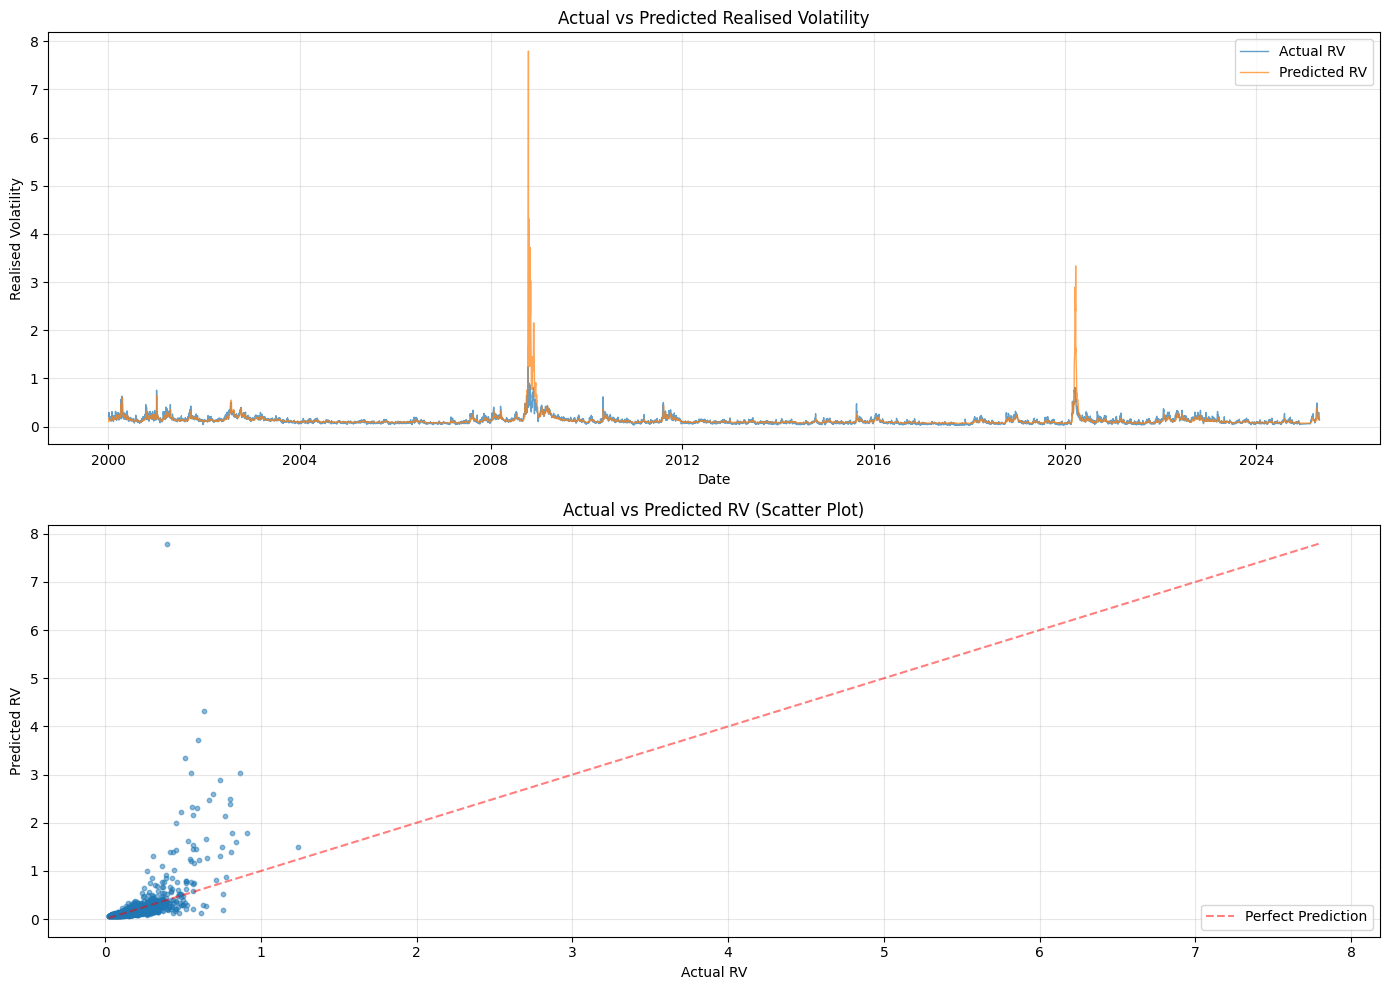

In [47]:
def har_forecast(filepath="SPY.csv"):
    print("="*60); print("HAR Forecast"); print("="*60)

    config = Config()
    # Key toggles (BIC per window is ON by default):
    # config.use_bic = True
    # config.feature_mode = "mean"      # or "lag"
    # config.use_log_transform = True

    print("\nLoading data...")
    rv_data = load_and_prepare_data(filepath)

    print(f"\nRunning expanding-window forecasting ...")
    results_df = expanding_window_forecast_HAR(rv_data, config)

    print_summary_statistics(results_df)
    print("\nGenerating plots...")
    plot_results(results_df)

if __name__ == "__main__":
    har_forecast()  # or har_forecast("path/to/your/SPY.csv")